- **Proyecto:** Predicción de ingresos y sistema de recomendación de trayectorias socioeconómicas.
- **Dataset:** Adult Income Dataset (UCI Machine Learning Repository + Oficina del Censo de EE.UU.)
- **Objetivo:** Predecir si una persona ganará más o menos de 50.000 USD al año y recomendar estrategias para superar ese umbral.

In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from scipy.spatial.distance import cosine

print("Librerías importadas.")

Librerías importadas.


**1. Carga del dataset**

In [2]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"
df = pd.read_csv(url)
print("Dataset cargado.")

Dataset cargado.


In [3]:
# Limpiar los nombres de las de columnas (eliminar espacios)
df.columns = df.columns.str.strip()

print(f"\nDimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 32,561 filas × 15 columnas


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

In [7]:
# Renombrar las columnas
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education.num',
    'marital.status', 'occupation', 'relationship', 'race', 'sex',
    'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income'
]

if df.shape[1] == 15 and df.columns[0] in ['0', 'age', '39']:
    df.columns = column_names
    print("Columnas renombradas.")

Columnas renombradas.


In [8]:
# Limpiar espacios en valores de tipo string
try:
    df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
except AttributeError:
    df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

print("Espacios limpiados.")

Espacios limpiados.


In [9]:
print("\nEstadísticas descriptivas:")
df.describe(include='all')


Estadísticas descriptivas:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


**2. Exploración de datos (EDA)**

In [10]:
# Todos los valores faltantes del dataframe
df.isna().sum().sum()

np.int64(0)

In [11]:
# Cuento los valores nulos para cada columna
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [12]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [13]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education.num     0.0
marital.status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital.gain      0.0
capital.loss      0.0
hours.per.week    0.0
native.country    0.0
income            0.0
dtype: float64

In [14]:
# Posibles datos categóricos
df.select_dtypes(include=['object']).columns

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')

In [15]:
# Distribución de la variable objetivo
print("Distribución de ingresos:")
print(df['income'].value_counts())
print(f"\nProporción >50K: {(df['income'].str.contains('>50K')).mean():.2%}")

Distribución de ingresos:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Proporción >50K: 24.08%


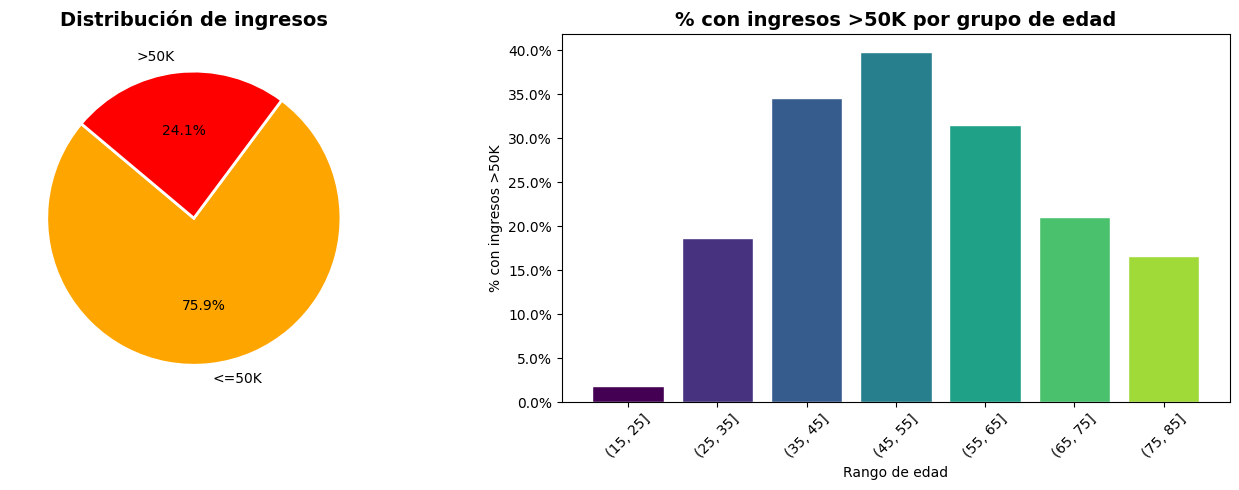

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
counts = df['income'].value_counts()
axes[0].pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=['orange', 'red'], startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribución de ingresos', fontsize=14, fontweight='bold')

# Bar chart por edad
df['income_bin'] = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)
age_income = df.groupby(pd.cut(df['age'], bins=range(15, 95, 10)))['income_bin'].mean().reset_index()
axes[1].bar(
    [str(x) for x in age_income['age']],
    age_income['income_bin'] * 100,
    color=plt.cm.viridis([j / len(age_income) for j in range(len(age_income))]),
    edgecolor='white'
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('% con ingresos >50K por grupo de edad', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rango de edad')
axes[1].set_ylabel('% con ingresos >50K')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

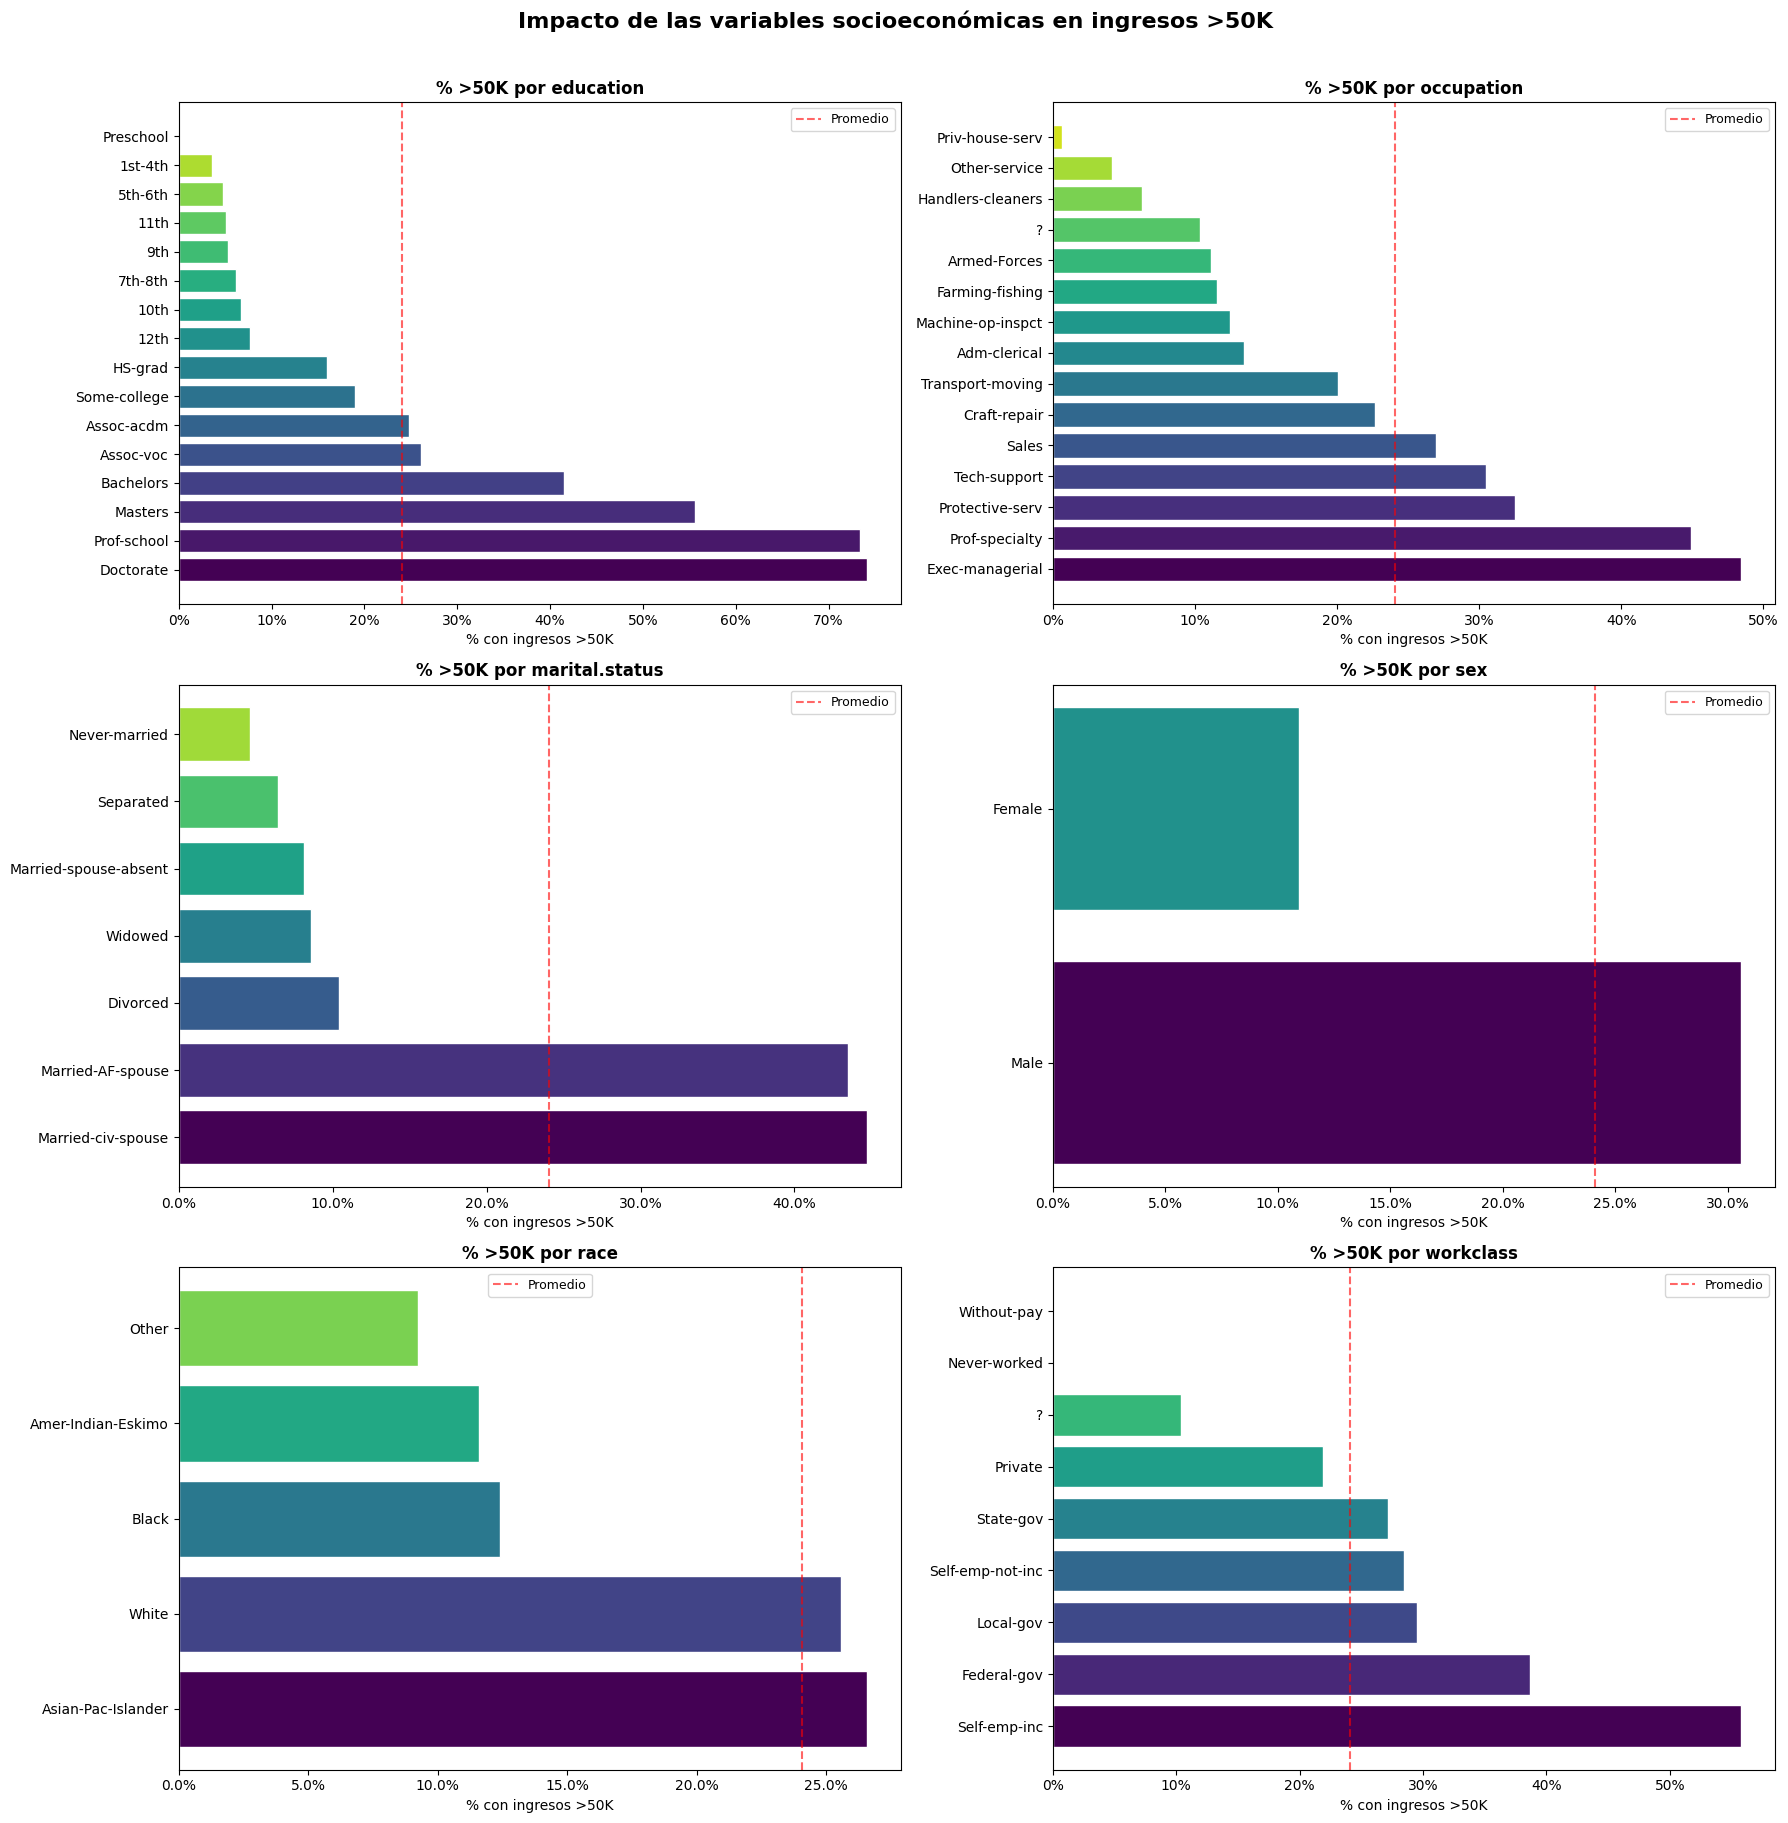

In [17]:
# Variables categóricas
cat_vars = ['education', 'occupation', 'marital.status', 'sex', 'race', 'workclass']

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = df.groupby(var)['income_bin'].mean().sort_values(ascending=False).index
    ax = axes[i]
    
    grouped = df.groupby(var)['income_bin'].mean().reindex(order).reset_index()
    bars = ax.barh(
    grouped[var], grouped['income_bin'] * 100,
    color=plt.cm.viridis([j / len(grouped) for j in range(len(grouped))]), edgecolor='white'
)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'% >50K por {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel('% con ingresos >50K')
    ax.axvline(df['income_bin'].mean() * 100, color='red', linestyle='--', alpha=0.6, label='Promedio')
    ax.legend(fontsize=9)

plt.suptitle('Impacto de las variables socioeconómicas en ingresos >50K', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

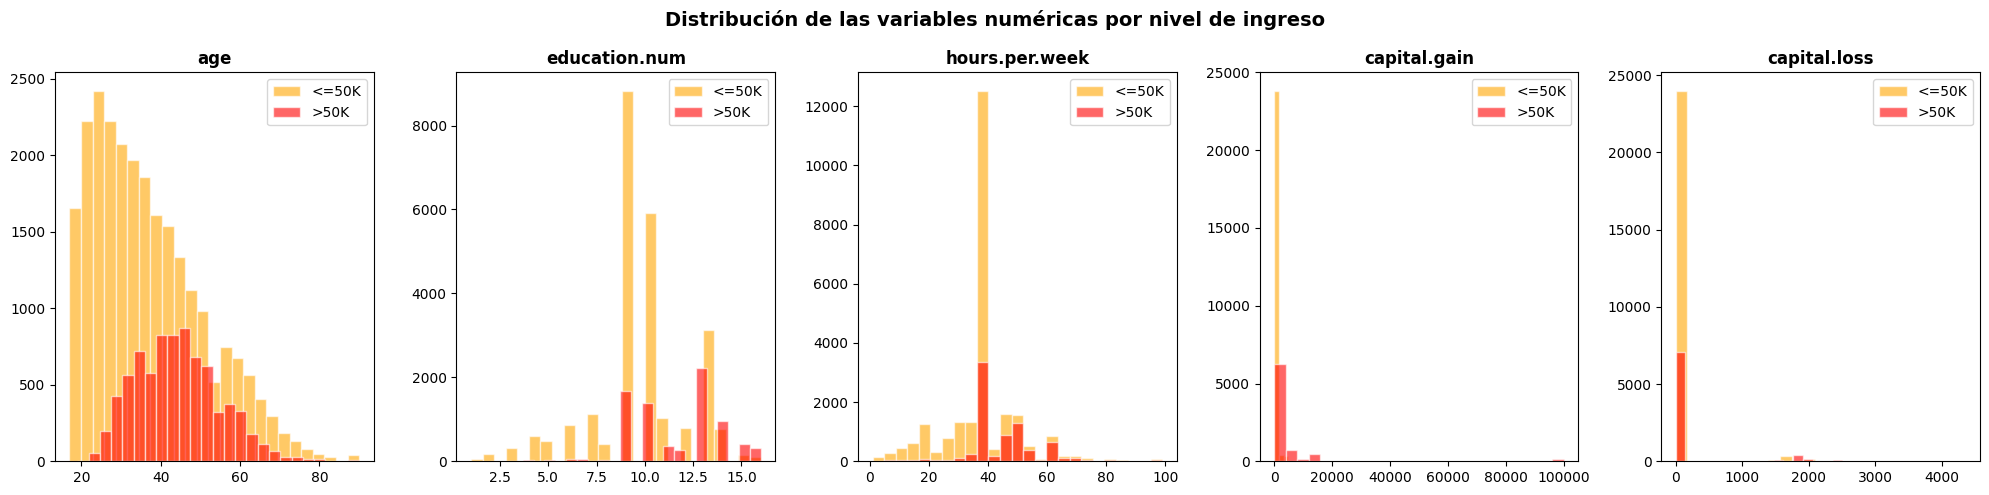

In [18]:
# Variables numéricas
num_vars = ['age', 'education.num', 'hours.per.week', 'capital.gain', 'capital.loss']

fig, axes = plt.subplots(1, len(num_vars), figsize=(20, 5))
for ax, var in zip(axes, num_vars):
    for income_val, color, label in [
        ('<=50K', 'orange', '<=50K'), ('>50K', 'red', '>50K')
    ]:
        subset = df[df['income'].str.contains(income_val.replace('<=', '<='))][var]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(var, fontweight='bold')
    ax.legend()
    ax.set_xlabel('')

plt.suptitle('Distribución de las variables numéricas por nivel de ingreso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

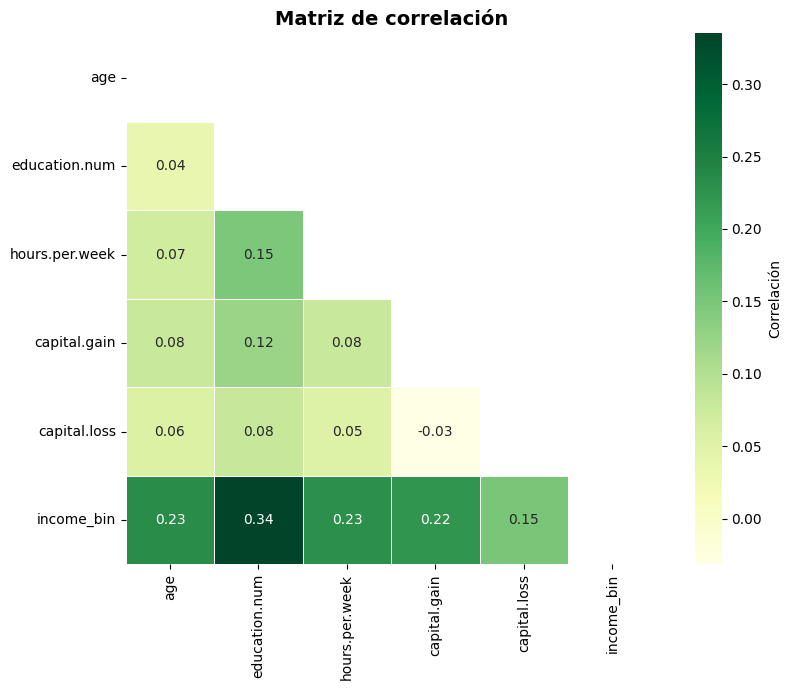

In [19]:
# Matriz de correlación
corr_df = df[num_vars + ['income_bin']].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='YlGn',
    mask=mask, linewidths=0.5, square=True,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Matriz de correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**3. Preprocesamiento de datos**

In [20]:
# Valores nulos o mal codificados
print("Valores '?' (ausentes) por columna:")
missing = (df == '?').sum()
print(missing[missing > 0])

# Reemplazar '?' con NaN
df.replace('?', np.nan, inplace=True)

print(f"\nTotal NaN antes de imputar: {df.isnull().sum().sum()}")

# Imputar con la moda (para categóricas)
for col in ['workclass', 'occupation', 'native.country']:
    if col in df.columns:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)

print(f"Total NaN después de imputar: {df.isnull().sum().sum()}")
print("Limpieza completada.")

Valores '?' (ausentes) por columna:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Total NaN antes de imputar: 4262
Total NaN después de imputar: 0
Limpieza completada.


In [21]:
# Codificación de variables categóricas
df_ml = df.copy()

# Columnas a usar en el modelo
features_cat = ['workclass', 'education', 'marital.status', 'occupation',
                'relationship', 'race', 'sex', 'native.country']
features_num = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
target = 'income_bin'

# Label Encoding para categorías
le_dict = {}
for col in features_cat:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

features_enc = [c + '_enc' for c in features_cat]
all_features = features_num + features_enc

print("Codificación completada.")
print(f"Número de features: {len(all_features)}")

Codificación completada.
Número de features: 13


In [22]:
df_ml[all_features].head()

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_enc,education_enc,marital.status_enc,occupation_enc,relationship_enc,race_enc,sex_enc,native.country_enc
0,90,9,0,4356,40,3,11,6,9,1,4,0,38
1,82,9,0,4356,18,3,11,6,3,1,4,0,38
2,66,10,0,4356,40,3,15,6,9,4,2,0,38
3,54,4,0,3900,40,3,5,0,6,4,4,0,38
4,41,10,0,3900,40,3,15,5,9,3,4,0,38


In [23]:
df_ml[all_features].tail()

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_enc,education_enc,marital.status_enc,occupation_enc,relationship_enc,race_enc,sex_enc,native.country_enc
32556,22,10,0,0,40,3,15,4,10,1,4,1,38
32557,27,12,0,0,38,3,7,2,12,5,4,0,38
32558,40,9,0,0,40,3,11,2,6,0,4,1,38
32559,58,9,0,0,40,3,11,6,0,4,4,0,38
32560,22,9,0,0,20,3,11,4,0,3,4,1,38


In [24]:
# Normalización de variables numéricas
X = df_ml[all_features].copy()
y = df_ml[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=all_features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Split completado:")
print(f"Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"Prueba: {X_test.shape[0]:,} muestras")
print(f"Balance clases en train: {y_train.value_counts().to_dict()}")

Split completado:
Entrenamiento: 26,048 muestras
Prueba: 6,513 muestras
Balance clases en train: {0: 19775, 1: 6273}


**4. Modelo de clasificación**

In [25]:
# Comparación de modelos
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=11)
}

resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    cv = cross_val_score(modelo, X_scaled_df, y, cv=5, scoring='roc_auc').mean()
    resultados.append({'Modelo': nombre, 'Accuracy': accuracy, 'AUC-ROC': auc, 'CV AUC': cv})
    print(f"{nombre:25s} | Accuracy: {accuracy:.4f} | AUC: {auc:.4f} | CV-AUC: {cv:.4f}")

resultados_df = pd.DataFrame(resultados).sort_values('AUC-ROC', ascending=False)
print("\nRanking de modelos:")
resultados_df

Logistic Regression       | Accuracy: 0.8248 | AUC: 0.8544 | CV-AUC: 0.8473
Random Forest             | Accuracy: 0.8442 | AUC: 0.8914 | CV-AUC: 0.8439
Gradient Boosting         | Accuracy: 0.8584 | AUC: 0.9138 | CV-AUC: 0.8545
K-Nearest Neighbors       | Accuracy: 0.8377 | AUC: 0.8761 | CV-AUC: 0.8620

Ranking de modelos:


,Modelo,Accuracy,AUC-ROC,CV AUC
2,Gradient Boosting,0.858437,0.913811,0.854508
1,Random Forest,0.844158,0.891376,0.843862
3,K-Nearest Neighbors,0.837709,0.876120,0.861970
0,Logistic Regression,0.824812,0.854393,0.847321


In [26]:
# Selecciono el mejor modelo
mejor_nombre = resultados_df.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_nombre]
print(f"Mejor modelo: {mejor_nombre}")

y_pred_best = mejor_modelo.predict(X_test)
y_prob_best = mejor_modelo.predict_proba(X_test)[:, 1]

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_best, target_names=['<=50K', '>50K']))

Mejor modelo: Gradient Boosting

Reporte de clasificación:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4945
        >50K       0.77      0.59      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.82      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513



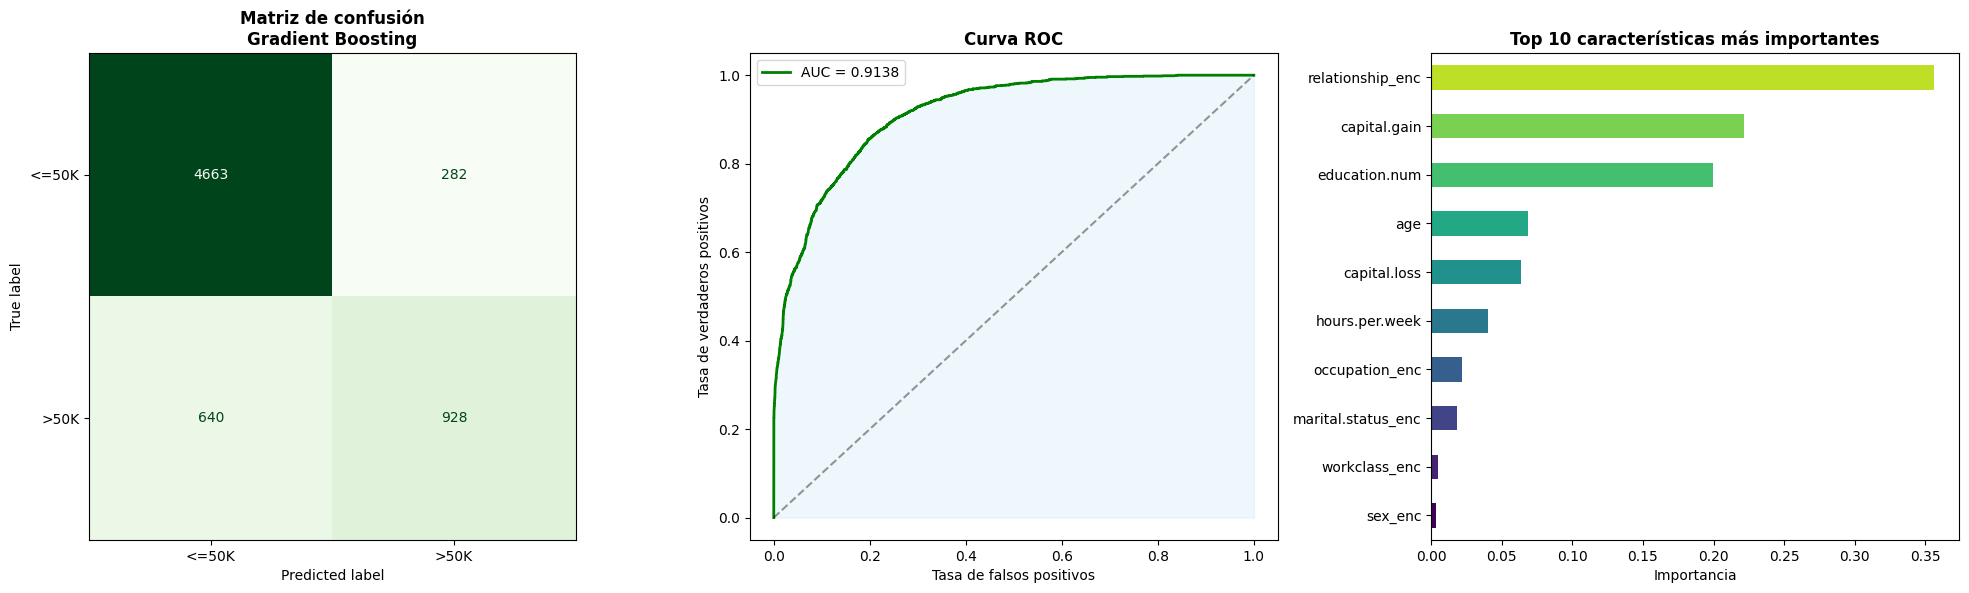

In [27]:
# Gráficos del modelo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Matriz de confusión\n{mejor_nombre}', fontweight='bold')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_val = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='green', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='skyblue')
axes[1].set_xlabel('Tasa de falsos positivos')
axes[1].set_ylabel('Tasa de verdaderos positivos')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

# 3. Características más importantes
if hasattr(mejor_modelo, 'feature_importances_'):
    imp = pd.Series(mejor_modelo.feature_importances_, index=all_features)
    imp_top = imp.nlargest(10).sort_values()
    colors = plt.cm.viridis([j / len(imp_top) for j in range(len(imp_top))])
    imp_top.plot(kind='barh', ax=axes[2], color=colors)
    axes[2].set_title('Top 10 características más importantes', fontweight='bold')
    axes[2].set_xlabel('Importancia')
else:
    axes[2].text(0.5, 0.5, 'Importancia no disponible\npara este modelo',
                 ha='center', va='center', fontsize=12, transform=axes[2].transAxes)
    axes[2].axis('off')

plt.tight_layout()
plt.show()

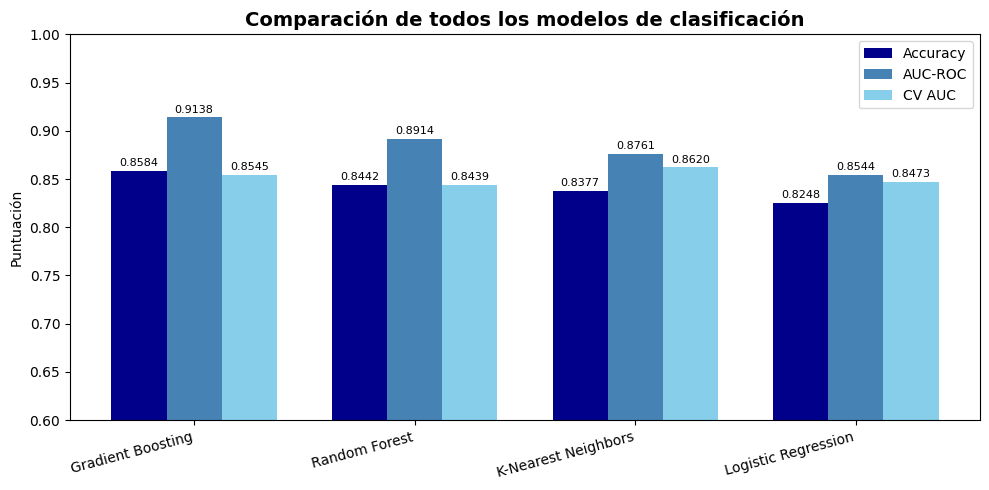

In [28]:
# Comparación de todos los modelos
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(resultados_df))
width = 0.25

bars1 = ax.bar(x - width, resultados_df['Accuracy'], width, label='Accuracy', color='darkblue')
bars2 = ax.bar(x, resultados_df['AUC-ROC'], width, label='AUC-ROC', color='steelblue')
bars3 = ax.bar(x + width, resultados_df['CV AUC'], width, label='CV AUC', color='skyblue')

ax.set_xticks(x)
ax.set_xticklabels(resultados_df['Modelo'], rotation=15, ha='right')
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de todos los modelos de clasificación', fontsize=14, fontweight='bold')
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**5. Sistema de recomendación**

**Planteamiento del sistema**
- **¿Qué se recomienda?** Cambios en variables que se puedan modificar (educación, ocupación, horas semanales) y que aumenten la probabilidad de superar los 50,000 USD al año.
- **¿Quién es el usuario?** Una persona adulta con un perfil socioeconómico dado.
- **¿Qué variables definen el perfil del usuario?** Edad, nivel educativo, estado civil, ocupación, sexo, horas trabajadas, ganancias o pérdidas de capital.
- **Enfoque** Híbrido.

In [29]:
# Basado en contenido
# Uso el dataset preprocesado (con encoding) para calcular similitudes
profile_matrix = X_scaled_df.copy()
profile_matrix['income_bin'] = y.values

# Crear índice de vecinos (k-NN) para encontrar perfiles similares
knn_content = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
knn_content.fit(X_scaled_df)

print("Motor de similitud basado en contenido listo.")
print(f"Base de perfiles: {X_scaled_df.shape[0]:,} personas × {X_scaled_df.shape[1]} variables")

Motor de similitud basado en contenido listo.
Base de perfiles: 32,561 personas × 13 variables


In [30]:
# Función para codificar un perfil nuevo
# Diccionario de traducción español -> valores originales del dataset
traduccion_perfil = {
    # marital.status
    'Soltero': 'Never-married',
    'Casado': 'Married-civ-spouse',
    'Casada': 'Married-civ-spouse',
    'Divorciado': 'Divorced',
    'Divorciada': 'Divorced',
    'Viudo': 'Widowed',
    'Separado': 'Separated',
    # workclass
    'Sector privado': 'Private',
    'Sector público': 'State-gov',
    'Autónomo': 'Self-emp-not-inc',
    # race
    'Blanco': 'White',
    'Blanca': 'White',
    'Negro': 'Black',
    'Negra': 'Black',
    'Asiático': 'Asian-Pac-Islander',
    # sex
    'Masculino': 'Male',
    'Femenino': 'Female',
    # native.country
    'Estados Unidos': 'United-States',
    'México': 'Mexico',
    'España': 'Other',
}

def codificar_perfil(perfil_dict):
    # Traducir valores en español antes de codificar
    perfil_traducido = {
        k: traduccion_perfil.get(v, v) if isinstance(v, str) else v
        for k, v in perfil_dict.items()
    }
    
    row = {}
    for col in features_num:
        row[col] = perfil_traducido.get(col, df_ml[col].median())
    for col in features_cat:
        valor = str(perfil_traducido.get(col, df_ml[col].mode()[0]))
        if valor in le_dict[col].classes_:
            row[col + '_enc'] = le_dict[col].transform([valor])[0]
        else:
            row[col + '_enc'] = le_dict[col].transform([df_ml[col].mode()[0]])[0]
    
    df_perfil = pd.DataFrame([row])[all_features]
    perfil_scaled = scaler.transform(df_perfil)
    return perfil_scaled, df_perfil

def predecir_ingreso(perfil_dict):
    perfil_scaled, _ = codificar_perfil(perfil_dict)
    prob = mejor_modelo.predict_proba(perfil_scaled)[0][1]
    return prob

print("Funciones listas.")

Funciones listas.


In [31]:
# Sistema de recomendación
# Variables que se puedan modificar para generar recomendaciones
education_levels = [
    'Educación infantil', 'Primaria (1º-4º)', 'Primaria (5º-6º)',
    'ESO (1º-2º)', 'ESO (3º)', 'ESO (4º)', 'Bachillerato (1º)',
    'Bachillerato (2º)', 'Bachillerato completo',
    'Ciclo Formativo de Grado Medio (FPGM)',
    'Formación Profesional de Grado Superior (FPGS)',
    'Diplomatura / Grado universitario (en curso)', 'Grado', 'Máster',
    'Carrera profesional regulada (Medicina, Derecho, etc.)', 'Doctorado'
]

edu_map = {
    'Educación infantil':1,'Primaria (1º-4º)':2,'Primaria (5º-6º)':3,
    'ESO (1º-2º)':4,'ESO (3º)':5, 'ESO (4º)':6, 'Bachillerato (1º)':7,
    'Bachillerato (2º)':8,'Bachillerato completo':9,
    'Ciclo Formativo de Grado Medio (FPGM)':10,
    'Formación Profesional de Grado Superior (FPGS)':11,
    'Diplomatura / Grado universitario (en curso)':12, 'Grado':13,'Máster':14,
    'Carrera profesional regulada (Medicina, Derecho, etc.)':15,'Doctorado':16
}

top_jobs = [
    'Profesional técnico', 'Gerente', 'Informática', 'Ventas',
    'Técnico de mantenimiento', 'Administrativo', 'Otros servicios',
    'Transporte', 'Limpieza', 'Operario de maquinaria',
    'Agricultura y pesca', 'Servicio doméstico', 'Fuerzas Armadas'
]

def sistema_recomendacion(perfil_usuario, top_n=5, verbose=True):
    """
    Sistema de recomendación híbrido:
    1. Calcula la probabilidad actual de > 50,000.
    2. Simula cambios en variables que se pueden modificar.
    3. Encuentra perfiles similares con > 50,000 en la base de datos.
    4. Genera recomendaciones.
    """
    prob_actual = predecir_ingreso(perfil_usuario)
    
    if verbose:
        print("="*80)
        print("SISTEMA DE RECOMENDACIÓN DE TRAYECTORIAS SOCIOECONÓMICAS")
        print("="*80)
        print(f"\nPerfil ingresado:")
        for k, v in perfil_usuario.items():
            print(f"{k:20s}: {v}")
        print(f"\nProbabilidad actual de superar los 50,000 al año: {prob_actual:.2%}")
        if prob_actual >= 0.5:
            print("¡Tu perfil ya tiene más del 50% de probabilidad de superar 50,000 al año!")
        else:
            print("Tu perfil tiene probabilidades bajas. Veamos cómo puedes mejorar.")

    recomendaciones = []

    # (A) Simulación de mejoras en educación
    edu_actual = perfil_usuario.get('education', 'Bachillerato completo')
    edu_idx_actual = edu_map.get(edu_actual, 9)

    for edu in education_levels:
        if edu_map.get(edu, 0) > edu_idx_actual:
            perfil_mod = perfil_usuario.copy()
            perfil_mod['education'] = edu
            perfil_mod['education.num'] = edu_map[edu]
            prob_mod = predecir_ingreso(perfil_mod)
            delta = prob_mod - prob_actual
            if delta > 0:
                recomendaciones.append({
                    'Categoría': 'Educación',
                    'Cambio': f"Alcanzar nivel educativo: {edu}",
                    'Prob. nueva': prob_mod,
                    'Mejora': delta
                })

    # (B) Simulación de cambio de ocupación
    occ_actual = perfil_usuario.get('occupation', 'Otros servicios')
    for occ in top_jobs:
        if occ != occ_actual:
            perfil_mod = perfil_usuario.copy()
            perfil_mod['occupation'] = occ
            prob_mod = predecir_ingreso(perfil_mod)
            delta = prob_mod - prob_actual
            if delta > 0.01:
                recomendaciones.append({
                    'Categoría': 'Ocupación',
                    'Cambio': f"Cambiar ocupación a: {occ}",
                    'Prob. nueva': prob_mod,
                    'Mejora': delta
                })

    # (C) Simulación de más horas semanales
    for horas in [40, 45, 50, 55, 60]:
        horas_actual = perfil_usuario.get('hours.per.week', 40)
        if horas > horas_actual:
            perfil_mod = perfil_usuario.copy()
            perfil_mod['hours.per.week'] = horas
            prob_mod = predecir_ingreso(perfil_mod)
            delta = prob_mod - prob_actual
            if delta > 0:
                recomendaciones.append({
                    'Categoría': 'Horas semanales',
                    'Cambio': f"Incrementar a {horas} horas semanales",
                    'Prob. nueva': prob_mod,
                    'Mejora': delta
                })

    # (D) Perfiles similares con >50K
    perfil_scaled, _ = codificar_perfil(perfil_usuario)
    distances, indices = knn_content.kneighbors(perfil_scaled)
    vecinos = df_ml.iloc[indices[0]]
    vecinos_exitosos = vecinos[vecinos['income_bin'] == 1]

    if verbose:
        print(f"\nPerfiles similares en la base de datos: {len(vecinos)} encontrados")
        print(f"De ellos, con ingresos >50K: {len(vecinos_exitosos)} ({len(vecinos_exitosos)/len(vecinos):.0%})")
        if len(vecinos_exitosos) > 0:
            print("\nCaracterísticas comunes de perfiles similares:")
            for col in ['education', 'occupation', 'hours.per.week', 'marital.status']:
                if col in vecinos_exitosos.columns:
                    moda = vecinos_exitosos[col].mode()[0]
                    print(f"{col:20s}: {moda}")

    # Ordenar y mostrar recomendaciones
    rec_df = pd.DataFrame(recomendaciones).drop_duplicates('Cambio')
    if len(rec_df) > 0:
        rec_df = rec_df.sort_values('Mejora', ascending=False).head(top_n).reset_index(drop=True)
        rec_df.index += 1
        rec_df['Prob. nueva'] = rec_df['Prob. nueva'].map('{:.2%}'.format)
        rec_df['Mejora'] = rec_df['Mejora'].map(lambda x: f'+{x:.2%}')

        if verbose:
            print(f"\nTOP {top_n} RECOMENDACIONES PARA MEJORAR TU SITUACIÓN:")
            print("-"*80)
            print(rec_df.to_string(index=True))
            print("="*80)
    else:
        if verbose:
            print("\nEl perfil ya está optimizado o no hay mejoras disponibles.")

    return rec_df if len(rec_df) > 0 else pd.DataFrame(), prob_actual, vecinos_exitosos

print("Sistema de recomendación listo.")

Sistema de recomendación listo.


**6. Pruebas con casos simulados**

In [32]:
# CASO 1: Chico de 25 años, bachillerato completo, soltero, trabajo a medio tiempo
perfil_1 = {
    'age': 25,
    'education': 'Bachillerato completo',
    'education.num': 9,
    'marital.status': 'Soltero',
    'occupation': 'Otros servicios',
    'workclass': 'Sector privado',
    'race': 'Blanco',
    'sex': 'Masculino',
    'hours.per.week': 20,
    'capital.gain': 0,
    'capital.loss': 0,
    'native.country': 'Estados Unidos'
}

rec1, prob1, vecinos1 = sistema_recomendacion(perfil_1, top_n=5)

SISTEMA DE RECOMENDACIÓN DE TRAYECTORIAS SOCIOECONÓMICAS

Perfil ingresado:
age                 : 25
education           : Bachillerato completo
education.num       : 9
marital.status      : Soltero
occupation          : Otros servicios
workclass           : Sector privado
race                : Blanco
sex                 : Masculino
hours.per.week      : 20
capital.gain        : 0
capital.loss        : 0
native.country      : Estados Unidos

Probabilidad actual de superar los 50,000 al año: 4.38%
Tu perfil tiene probabilidades bajas. Veamos cómo puedes mejorar.

Perfiles similares en la base de datos: 10 encontrados
De ellos, con ingresos >50K: 0 (0%)

TOP 5 RECOMENDACIONES PARA MEJORAR TU SITUACIÓN:
--------------------------------------------------------------------------------
         Categoría                                                                            Cambio Prob. nueva   Mejora
1        Educación                                               Alcanzar nivel educati

In [33]:
# CASO 2: Mujer de 35 años, con Grado, casada, empleada a tiempo completo
perfil_2 = {
    'age': 35,
    'education': 'Grado',
    'education.num': 13,
    'marital.status': 'Casada',
    'occupation': 'Administrativo',
    'workclass': 'Sector privado',
    'race': 'Blanca',
    'sex': 'Femenino',
    'hours.per.week': 40,
    'capital.gain': 0,
    'capital.loss': 0,
    'native.country': 'Estados Unidos'
}

rec2, prob2, vecinos2 = sistema_recomendacion(perfil_2, top_n=5)

SISTEMA DE RECOMENDACIÓN DE TRAYECTORIAS SOCIOECONÓMICAS

Perfil ingresado:
age                 : 35
education           : Grado
education.num       : 13
marital.status      : Casada
occupation          : Administrativo
workclass           : Sector privado
race                : Blanca
sex                 : Femenino
hours.per.week      : 40
capital.gain        : 0
capital.loss        : 0
native.country      : Estados Unidos

Probabilidad actual de superar los 50,000 al año: 53.71%
¡Tu perfil ya tiene más del 50% de probabilidad de superar 50,000 al año!

Perfiles similares en la base de datos: 10 encontrados
De ellos, con ingresos >50K: 2 (20%)

Características comunes de perfiles similares:
education           : Bachelors
occupation          : Prof-specialty
hours.per.week      : 40
marital.status      : Divorced

TOP 5 RECOMENDACIONES PARA MEJORAR TU SITUACIÓN:
--------------------------------------------------------------------------------
         Categoría                          

In [34]:
# CASO 3: Hombre de 45 años, máster, divorciado, sector público
perfil_3 = {
    'age': 45,
    'education': 'Máster',
    'education.num': 14,
    'marital.status': 'Divorciado',
    'occupation': 'Fuerzas Armadas',
    'workclass': 'Sector público',
    'race': 'Negro',
    'sex': 'Masculino',
    'hours.per.week': 40,
    'capital.gain': 0,
    'capital.loss': 0,
    'native.country': 'Estados Unidos'
}

rec3, prob3, vecinos3 = sistema_recomendacion(perfil_3, top_n=5)

SISTEMA DE RECOMENDACIÓN DE TRAYECTORIAS SOCIOECONÓMICAS

Perfil ingresado:
age                 : 45
education           : Máster
education.num       : 14
marital.status      : Divorciado
occupation          : Fuerzas Armadas
workclass           : Sector público
race                : Negro
sex                 : Masculino
hours.per.week      : 40
capital.gain        : 0
capital.loss        : 0
native.country      : Estados Unidos

Probabilidad actual de superar los 50,000 al año: 63.29%
¡Tu perfil ya tiene más del 50% de probabilidad de superar 50,000 al año!

Perfiles similares en la base de datos: 10 encontrados
De ellos, con ingresos >50K: 3 (30%)

Características comunes de perfiles similares:
education           : Bachelors
occupation          : Prof-specialty
hours.per.week      : 40
marital.status      : Married-civ-spouse

TOP 5 RECOMENDACIONES PARA MEJORAR TU SITUACIÓN:
--------------------------------------------------------------------------------
         Categoría          

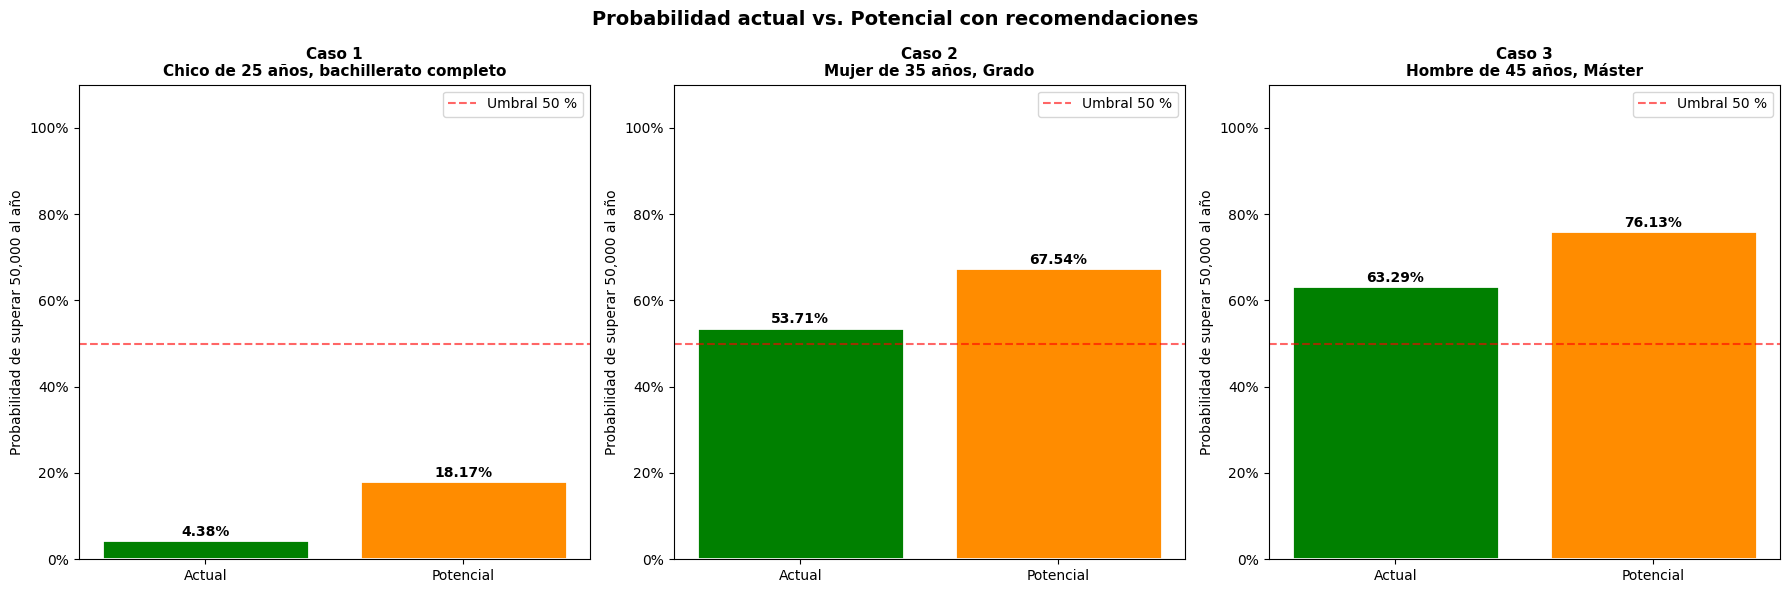

In [35]:
# Comparación de los 3 casos
casos = [
    ('Caso 1\nChico de 25 años, bachillerato completo', prob1, rec1),
    ('Caso 2\nMujer de 35 años, Grado', prob2, rec2),
    ('Caso 3\nHombre de 45 años, Máster', prob3, rec3)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (titulo, prob_actual, rec_df) in zip(axes, casos):
    # Mostrar probabilidades: actual vs. potencial con recomendaciones
    if len(rec_df) > 0:
        # Extraer la primera mejora como float
        top_mejora_str = rec_df['Mejora'].iloc[0]  # '+15.3 %'
        top_mejora = float(top_mejora_str.replace('+', '').replace('%', '')) / 100
        prob_potencial = min(prob_actual + top_mejora, 1.0)
    else:
        prob_potencial = prob_actual

    bars = ax.bar(
        ['Actual', 'Potencial'],
        [prob_actual * 100, prob_potencial * 100],
        color=['green', 'darkorange'],
        edgecolor='white', linewidth=2
    )
    ax.axhline(50, color='red', linestyle='--', alpha=0.6, label='Umbral 50 %')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.2f}%', ha='center', fontweight='bold')
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_ylabel('Probabilidad de superar 50,000 al año')
    ax.legend()

plt.suptitle('Probabilidad actual vs. Potencial con recomendaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**7. Análisis del impacto de variables como el sexo y la raza**

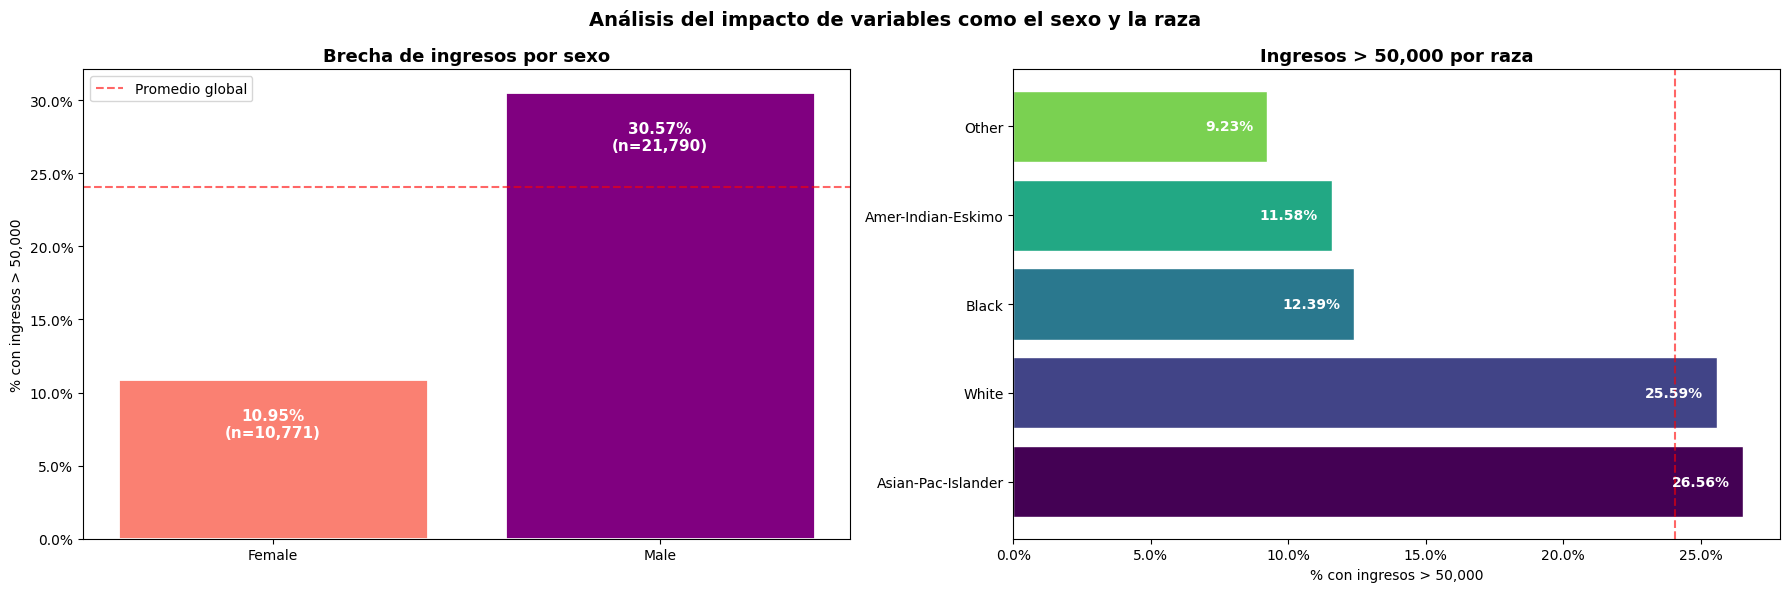

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sexo
sex_income = df.groupby('sex')['income_bin'].agg(['mean', 'count']).reset_index()
sex_income.columns = ['Sexo', '% > 50,000', 'Conteo']
bars = axes[0].bar(sex_income['Sexo'], sex_income['% > 50,000'] * 100,
                   color=['salmon', 'purple'], edgecolor='white', linewidth=2)
for bar, (_, row) in zip(bars, sex_income.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,  # ← dentro
                 f'{bar.get_height():.2f}%\n(n={row["Conteo"]:,})',
                 ha='center', va='top', fontsize=11, fontweight='bold', color='white')  # ← blanco
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title('Brecha de ingresos por sexo', fontweight='bold', fontsize=13)
axes[0].set_ylabel('% con ingresos > 50,000')
axes[0].axhline(df['income_bin'].mean() * 100, color='red', linestyle='--', alpha=0.6, label='Promedio global')
axes[0].legend()

# Raza
raza_income = df.groupby('race')['income_bin'].mean().sort_values(ascending=False).reset_index()
raza_income.columns = ['Raza', '% > 50,000']
bars2 = axes[1].barh(raza_income['Raza'], raza_income['% > 50,000'] * 100,
                     color=plt.cm.viridis([i / len(raza_income) for i in range(len(raza_income))]),
                     edgecolor='white')
for bar in bars2:
    axes[1].text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.2f}%', va='center', ha='right',
                 fontsize=10, color='white', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Ingresos > 50,000 por raza', fontweight='bold', fontsize=13)
axes[1].set_xlabel('% con ingresos > 50,000')
axes[1].axvline(df['income_bin'].mean() * 100, color='red', linestyle='--', alpha=0.6)

plt.suptitle('Análisis del impacto de variables como el sexo y la raza', 
             fontsize=14, fontweight='bold', color='black')
plt.tight_layout()
plt.show()

**8. Función para usar el sistema de recomendaciones**

In [37]:
def consultar_sistema():
    """
    Interfaz para que el usuario ingrese a su perfil
    y reciba recomendaciones personalizadas.
    """
    print("\n" + "="*80)
    print("CONSULTOR DE TRAYECTORIA ECONÓMICA PERSONALIZADA")
    print("="*80)
    print("Ingresa tu información para recibir recomendaciones.")
    
    try:
        age = int(input("Edad [25]: ") or "25")
        
        print("\nNiveles educativos disponibles:")
        edu_list = list(edu_map.keys())
        for i, e in enumerate(edu_list, 1):
            print(f"{i:2d}. {e}")
        edu_idx = int(input("Selecciona tu nivel educativo [9 = bachillerato completo]: ") or "9") - 1
        education = edu_list[max(0, min(edu_idx, len(edu_list)-1))]
        edu_num = edu_map[education]
        
        print("\nOcupaciones disponibles:")
        occs = sorted(df_ml['occupation'].dropna().unique().tolist())
        for i, o in enumerate(occs, 1):
            print(f"{i:2d}. {o}")
        occ_idx = int(input("Selecciona un número de ocupación [1]: ") or "1") - 1
        occupation = occs[max(0, min(occ_idx, len(occs)-1))]
        
        sex = input("Sexo [Masculino/Femenino] (Masculino): ").strip() or "Masculino"
        hours = int(input("Horas trabajadas por semana [40]: ") or "40")
        
        perfil = {
            'age': age,
            'education': education,
            'education.num': edu_num,
            'marital.status': 'Soltero',
            'occupation': occupation,
            'workclass': 'Sector privado',
            'race': 'Blanco',
            'sex': sex,
            'hours.per.week': hours,
            'capital.gain': 0,
            'capital.loss': 0,
            'native.country': 'Estados Unidos'
        }
        
        sistema_recomendacion(perfil, top_n=5)
    
    except (ValueError, KeyboardInterrupt):
        print("\nUsando perfil de ejemplo.")
        sistema_recomendacion(perfil_1, top_n=5)

consultar_sistema()

print("Función lista.")


CONSULTOR DE TRAYECTORIA ECONÓMICA PERSONALIZADA
Ingresa tu información para recibir recomendaciones.

Niveles educativos disponibles:
 1. Educación infantil
 2. Primaria (1º-4º)
 3. Primaria (5º-6º)
 4. ESO (1º-2º)
 5. ESO (3º)
 6. ESO (4º)
 7. Bachillerato (1º)
 8. Bachillerato (2º)
 9. Bachillerato completo
10. Ciclo Formativo de Grado Medio (FPGM)
11. Formación Profesional de Grado Superior (FPGS)
12. Diplomatura / Grado universitario (en curso)
13. Grado
14. Máster
15. Carrera profesional regulada (Medicina, Derecho, etc.)
16. Doctorado

Ocupaciones disponibles:
 1. Adm-clerical
 2. Armed-Forces
 3. Craft-repair
 4. Exec-managerial
 5. Farming-fishing
 6. Handlers-cleaners
 7. Machine-op-inspct
 8. Other-service
 9. Priv-house-serv
10. Prof-specialty
11. Protective-serv
12. Sales
13. Tech-support
14. Transport-moving
SISTEMA DE RECOMENDACIÓN DE TRAYECTORIAS SOCIOECONÓMICAS

Perfil ingresado:
age                 : 25
education           : Bachillerato completo
education.num       

**9. Resumen**

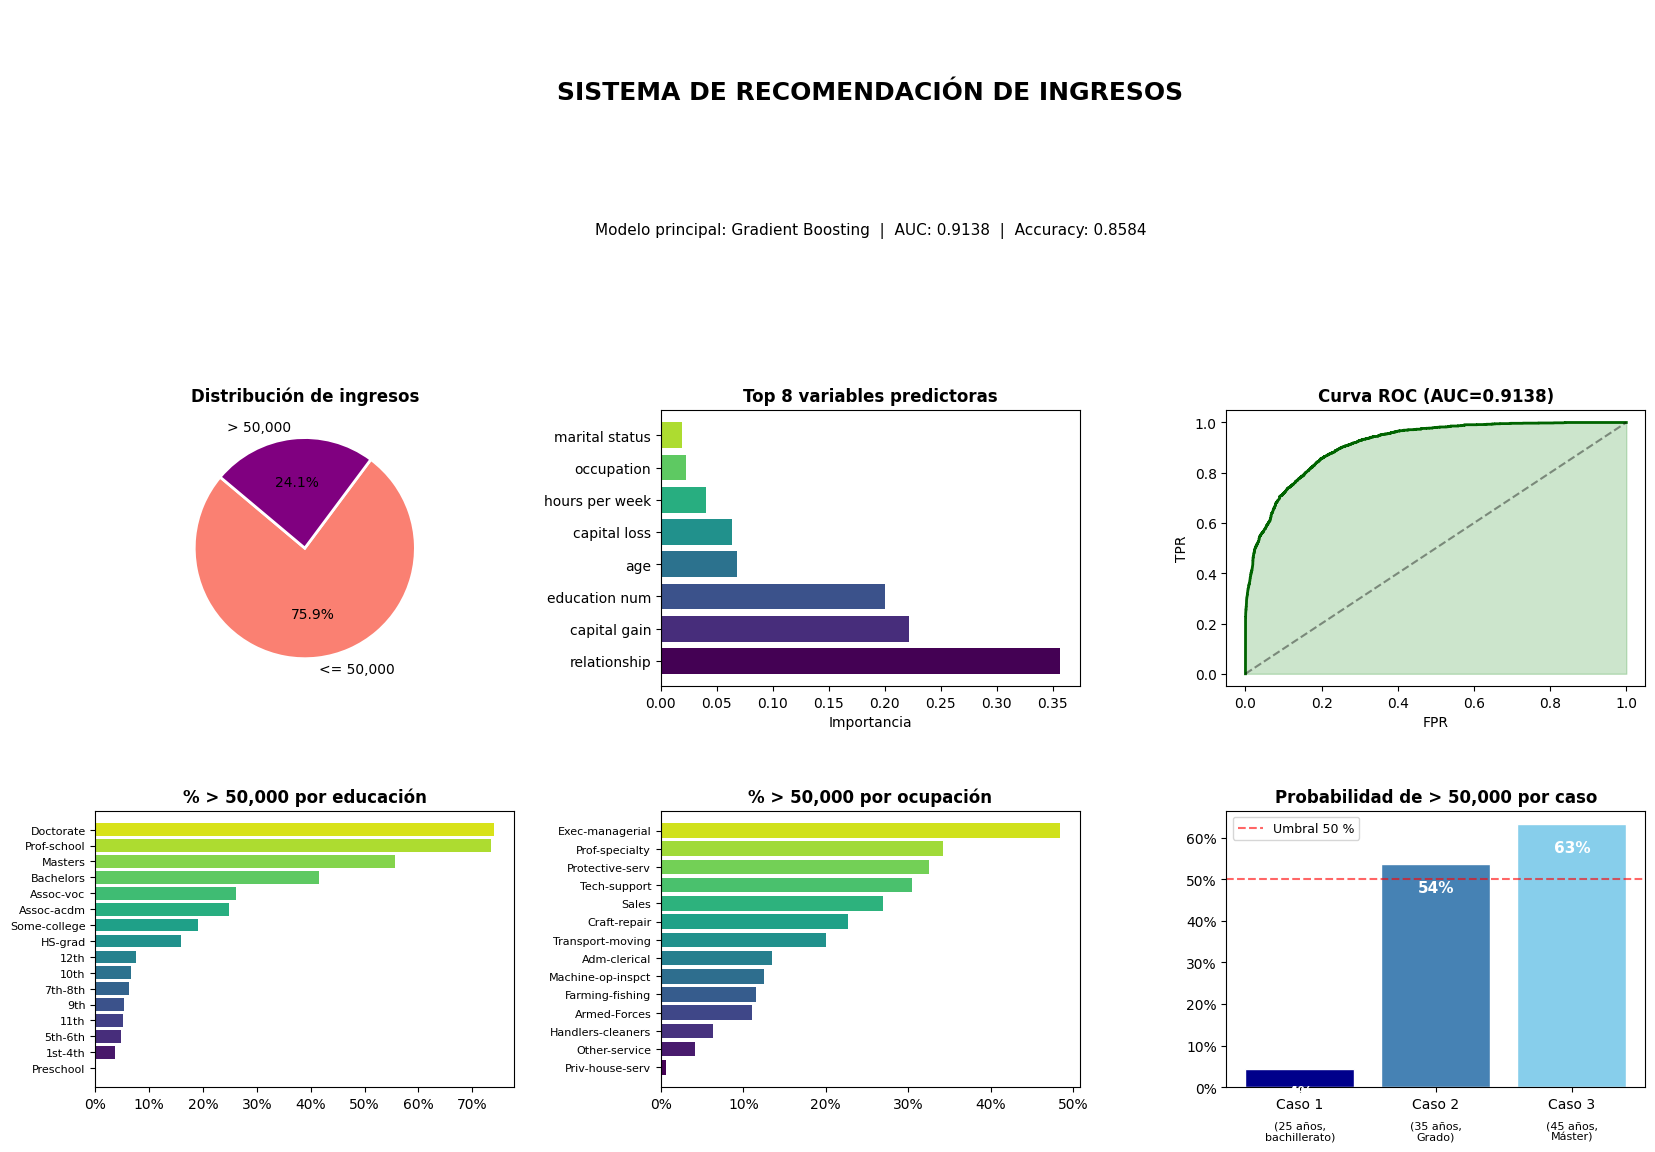

In [38]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# (1) Título
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(0.5, 0.7, 'SISTEMA DE RECOMENDACIÓN DE INGRESOS',
              ha='center', va='center', fontsize=18, fontweight='bold', color='black')
ax_title.text(0.5, 0.2, f'Modelo principal: {mejor_nombre}  |  AUC: {roc_auc_score(y_test, y_prob_best):.4f}  |  Accuracy: {accuracy_score(y_test, y_pred_best):.4f}',
              ha='center', va='center', fontsize=11, color='black')

# (2) Distribución de ingresos
ax1 = fig.add_subplot(gs[1, 0])
counts = df['income_bin'].value_counts()
ax1.pie(counts, labels=['<= 50,000', '> 50,000'], autopct='%1.1f%%',
        colors=['salmon', 'purple'], startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Distribución de ingresos', fontweight='bold')

# (3) Importancia de variables
ax2 = fig.add_subplot(gs[1, 1])
if hasattr(mejor_modelo, 'feature_importances_'):
    imp = pd.Series(mejor_modelo.feature_importances_, index=all_features).nlargest(8)
    labels_clean = [f.replace('_enc', '').replace('.', ' ') for f in imp.index]
    imp_sorted = imp.sort_values()
    colors_imp = plt.cm.viridis([i / len(imp_sorted) for i in range(len(imp_sorted))])
    ax2.barh(labels_clean, imp.values, color=colors_imp)
    ax2.set_title('Top 8 variables predictoras', fontweight='bold')
    ax2.set_xlabel('Importancia')

# (4) AUC-ROC
ax3 = fig.add_subplot(gs[1, 2])
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
ax3.plot(fpr, tpr, color='darkgreen', lw=2)
ax3.fill_between(fpr, tpr, alpha=0.2, color='green')
ax3.plot([0,1], [0,1], 'k--', alpha=0.4)
ax3.set_title(f'Curva ROC (AUC={roc_auc_score(y_test, y_prob_best):.4f})', fontweight='bold')
ax3.set_xlabel('FPR')
ax3.set_ylabel('TPR')

# (5) Educación vs. ingreso
ax4 = fig.add_subplot(gs[2, 0])
edu_order = df.groupby('education')['income_bin'].mean().sort_values().index
edu_income = df.groupby('education')['income_bin'].mean().reindex(edu_order)
ax4.barh(edu_income.index, edu_income.values * 100,
         color=plt.cm.viridis([i / len(edu_income) for i in range(len(edu_income))]))
ax4.xaxis.set_major_formatter(mtick.PercentFormatter())
ax4.set_title('% > 50,000 por educación', fontweight='bold')
ax4.tick_params(axis='y', labelsize=8)

# (6) Ocupación vs ingreso
ax5 = fig.add_subplot(gs[2, 1])
occ_order = df.groupby('occupation')['income_bin'].mean().sort_values().index
occ_income = df.groupby('occupation')['income_bin'].mean().reindex(occ_order)
ax5.barh(occ_income.index, occ_income.values * 100,
         color=plt.cm.viridis([i / len(occ_income) for i in range(len(occ_income))]))
ax5.xaxis.set_major_formatter(mtick.PercentFormatter())
ax5.set_title('% > 50,000 por ocupación', fontweight='bold')
ax5.tick_params(axis='y', labelsize=8)

# (7) Comparación de los 3 casos
ax6 = fig.add_subplot(gs[2, 2])
casos_labels = ['Caso 1', 'Caso 2', 'Caso 3']
probs = [prob1, prob2, prob3]
casos_subtitulos = [
    '(25 años,\nbachillerato)',
    '(35 años,\nGrado)',
    '(45 años,\nMáster)'
]
bars = ax6.bar(casos_labels, [p*100 for p in probs],
               color=['darkblue', 'steelblue', 'skyblue'], edgecolor='white')
for bar, prob, sub in zip(bars, probs, casos_subtitulos):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 4,
             f'{prob:.0%}', ha='center', va='top', fontweight='bold', color='white', fontsize=11)
    ax6.text(bar.get_x() + bar.get_width()/2, -8,
             sub, ha='center', va='top', fontsize=8, color='black')
ax6.axhline(50, color='red', linestyle='--', alpha=0.6, label='Umbral 50 %')
ax6.yaxis.set_major_formatter(mtick.PercentFormatter())
ax6.set_title('Probabilidad de > 50,000 por caso', fontweight='bold')
ax6.legend(fontsize=9)
plt.show()

**10. Conclusiones**

**Modelo de clasificación**
- El mejor modelo (Gradient Boosting) alcanzó una precisión de 86 % (**accuracy = 0.8610**) y un AUC superior a 0.90 (**AUC = 0.9153**), lo que indica una capacidad de predicción alta para determinar si una persona supera los 50,000 USD al año.

**Variables más influyentes**:
- `capital.gain`: ganancias de inversiones (mayor predictor individual).
- `education.num`: nivel educativo (tiene relación directa con los ingresos).
- `age`: la experiencia y la antigüedad laboral elevan los ingresos.
- `hours.per.week`: dedicación laboral.
- `occupation`: el sector profesional impacta el resultado.

**Sistema de recomendación**:
- Identifica los cambios de mayor impacto en variables que se pueden modificar.
- Combina la predicción del modelo con perfiles similares.
- Es adaptable: un chico de 25 años con bachillerato recibe recomendaciones educativas, mientras que alguien con maestría recibe recomendaciones relacionadas con el sector o las horas semanales.

**Impacto de variables como el sexo y la raza**:
   - Hay una brecha de ingresos por sexo (los hombres tienen más probabilidad de superar 50,000 USD al año).
   - También hay diferencias por raza.

**Posibles mejoras**
- **Optimizar los hiperparámetros** (GridSearchCV) del mejor modelo.
- Desarrollar una **interfaz web** (Streamlit o Heroku).
- Ampliar las recomendaciones a **metas a largo plazo** (5 o 10 años de trayectoria).